# Does Concentration or Diversification Win? It Depends on the Market and the Sector

A common piece of investing advice is that diversification reduces risk without sacrificing much return. This analysis tests that claim directly, comparing a concentrated portfolio against an eight-asset diversified portfolio across different market conditions and different sectors, using real historical price data.

**Method:** Daily price data pulled programmatically via the `yfinance` API, loaded into a SQLite database, with return calculations, portfolio construction, and aggregation performed primarily in SQL using window functions, joins, and CTEs. Python and pandas handle the final statistical summary (annualized return, volatility, and Sharpe ratio) and visualization.

**Finding:** Whether concentration outperforms diversification depends heavily on two separate factors: the existing market conditions (bull market vs. crisis) and the specific sector of concentration. Neither factor alone tells the full story.

## Data and Method

Daily closing prices for 11 tickers were pulled directly from Yahoo Finance, covering two portfolios: a concentrated four-stock portfolio (initially tech: AAPL, MSFT, NVDA, GOOGL) and a diversified eight-asset portfolio spanning tech, healthcare, energy, financials, consumer staples, real estate, bonds, and gold.

Rather than calculating returns in pandas, this analysis pushes that work into SQL, reflecting how data more often lives in practice: queried from a real database, not a static CSV. The pipeline: prices are reshaped into long format, daily returns are calculated with a window function (`LAG` partitioned by ticker), then joined against a portfolio mapping table and aggregated into one average daily return per portfolio per day.

To make this pipeline reusable across multiple time periods and sectors, without repeating the same code, it was wrapped in a single function, `analyze_portfolios`, taking a ticker list, sector label, and date range as arguments.

In [1]:
import yfinance as yf
import pandas as pd
import sqlite3

#Define Portfolios and pull data from Yahoo Finance
concentrated = ["AAPL", "MSFT", "NVDA", "GOOGL"]
diversified = ["AAPL", "JNJ", "XOM", "JPM", "PG", "VNQ", "TLT", "GLD"]

all_tickers = list(set(concentrated + diversified))

data = yf.download(all_tickers, start="2021-01-01", end="2025-01-01", progress=False)["Close"]
print(data.head())
print(data.shape)

Ticker            AAPL         GLD      GOOGL         JNJ         JPM  \
Date                                                                    
2021-01-04  125.632492  182.330002  85.492973  133.628342  109.000526   
2021-01-05  127.185783  182.869995  86.182419  135.199402  109.593636   
2021-01-06  122.904518  179.899994  85.332024  136.471634  114.739700   
2021-01-07  127.098427  179.479996  87.880753  136.932755  118.507675   
2021-01-08  128.195404  173.339996  89.044182  136.650955  118.638489   

Ticker            MSFT       NVDA          PG         TLT        VNQ  \
Date                                                                   
2021-01-04  207.565384  13.046199  118.965553  130.697327  66.358498   
2021-01-05  207.765625  13.335955  119.725159  129.726669  66.455406   
2021-01-06  202.378387  12.549760  120.985451  127.063652  66.568474   
2021-01-07  208.137512  13.275516  119.854637  125.943573  66.439255   
2021-01-08  209.405579  13.208608  119.802856  125.53712

In [2]:
#Load data into SQLite
conn = sqlite3.connect("portfolio.db")

data_reset = data.reset_index()
data_reset.to_sql("prices", conn, if_exists="replace", index=False)

check = pd.read_sql("SELECT * FROM prices LIMIT 5", conn)
print(check)

                  Date        AAPL         GLD      GOOGL         JNJ  \
0  2021-01-04 00:00:00  125.632492  182.330002  85.492973  133.628342   
1  2021-01-05 00:00:00  127.185783  182.869995  86.182419  135.199402   
2  2021-01-06 00:00:00  122.904518  179.899994  85.332024  136.471634   
3  2021-01-07 00:00:00  127.098427  179.479996  87.880753  136.932755   
4  2021-01-08 00:00:00  128.195404  173.339996  89.044182  136.650955   

          JPM        MSFT       NVDA          PG         TLT        VNQ  \
0  109.000526  207.565384  13.046199  118.965553  130.697327  66.358498   
1  109.593636  207.765625  13.335955  119.725159  129.726669  66.455406   
2  114.739700  202.378387  12.549760  120.985451  127.063652  66.568474   
3  118.507675  208.137512  13.275516  119.854637  125.943573  66.439255   
4  118.638489  209.405579  13.208608  119.802856  125.537125  67.085312   

         XOM  
0  33.251335  
1  34.853802  
2  35.743176  
3  36.023613  
4  36.424221  


In [3]:
#Calculate daily returns in SQL
returns_query = """
SELECT Date, AAPL,
    (AAPL - LAG(AAPL) OVER (ORDER BY Date)) / LAG(AAPL) OVER (ORDER BY Date) AS AAPL_daily_return
FROM prices
LIMIT 10;
"""
print(pd.read_sql(returns_query, conn))

                  Date        AAPL  AAPL_daily_return
0  2021-01-04 00:00:00  125.632492                NaN
1  2021-01-05 00:00:00  127.185783           0.012364
2  2021-01-06 00:00:00  122.904518          -0.033662
3  2021-01-07 00:00:00  127.098427           0.034123
4  2021-01-08 00:00:00  128.195404           0.008631
5  2021-01-11 00:00:00  125.215027          -0.023249
6  2021-01-12 00:00:00  125.040314          -0.001395
7  2021-01-13 00:00:00  127.069290           0.016227
8  2021-01-14 00:00:00  125.147072          -0.015127
9  2021-01-15 00:00:00  123.428764          -0.013730


In [4]:
#Reshape data to long format for simpler calculations
long_data = data_reset.melt(id_vars="Date", var_name="Ticker", value_name="Price")
print(long_data.head())

long_data.to_sql("prices_long", conn, if_exists="replace", index=False)

        Date Ticker       Price
0 2021-01-04   AAPL  125.632492
1 2021-01-05   AAPL  127.185783
2 2021-01-06   AAPL  122.904518
3 2021-01-07   AAPL  127.098427
4 2021-01-08   AAPL  128.195404


11055

In [5]:
#Recalculate returns for all tickers
returns_query = """
SELECT Date, Ticker, Price,
    (Price - LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date)) / LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date) AS daily_return
FROM prices_long
"""
returns_long = pd.read_sql(returns_query, conn)
print(returns_long.head(15))

                   Date Ticker       Price  daily_return
0   2021-01-04 00:00:00   AAPL  125.632492           NaN
1   2021-01-05 00:00:00   AAPL  127.185783      0.012364
2   2021-01-06 00:00:00   AAPL  122.904518     -0.033662
3   2021-01-07 00:00:00   AAPL  127.098427      0.034123
4   2021-01-08 00:00:00   AAPL  128.195404      0.008631
5   2021-01-11 00:00:00   AAPL  125.215027     -0.023249
6   2021-01-12 00:00:00   AAPL  125.040314     -0.001395
7   2021-01-13 00:00:00   AAPL  127.069290      0.016227
8   2021-01-14 00:00:00   AAPL  125.147072     -0.015127
9   2021-01-15 00:00:00   AAPL  123.428764     -0.013730
10  2021-01-19 00:00:00   AAPL  124.098610      0.005427
11  2021-01-20 00:00:00   AAPL  128.176025      0.032856
12  2021-01-21 00:00:00   AAPL  132.874741      0.036658
13  2021-01-22 00:00:00   AAPL  135.010559      0.016074
14  2021-01-25 00:00:00   AAPL  138.748154      0.027684


In [6]:
#Create portfolio variable and calculate returns by portfolio
portfolio_map = pd.DataFrame({
    "Ticker": ["AAPL", "MSFT", "NVDA", "GOOGL", "AAPL", "JNJ", "XOM", "JPM", "PG", "VNQ", "TLT", "GLD"],
    "Portfolio": ["Concentrated"]*4 + ["Diversified"]*8
})

portfolio_map.to_sql("portfolio_map", conn, if_exists="replace", index=False)

portfolio_returns_query = """
SELECT prices_long.Date, portfolio_map.Portfolio, AVG(prices_long.daily_return) AS portfolio_return
FROM (
    SELECT Date, Ticker,
        (Price - LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date)) / LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date) AS daily_return
    FROM prices_long
) AS prices_long
INNER JOIN portfolio_map ON prices_long.Ticker = portfolio_map.Ticker
GROUP BY prices_long.Date, portfolio_map.Portfolio
"""
portfolio_returns = pd.read_sql(portfolio_returns_query, conn)
print(portfolio_returns.head(10))
print(portfolio_returns.shape)

                  Date     Portfolio  portfolio_return
0  2021-01-04 00:00:00  Concentrated               NaN
1  2021-01-04 00:00:00   Diversified               NaN
2  2021-01-05 00:00:00  Concentrated          0.010901
3  2021-01-05 00:00:00   Diversified          0.010142
4  2021-01-06 00:00:00  Concentrated         -0.032103
5  2021-01-06 00:00:00   Diversified          0.002960
6  2021-01-07 00:00:00  Concentrated          0.037570
7  2021-01-07 00:00:00   Diversified          0.006969
8  2021-01-08 00:00:00  Concentrated          0.005731
9  2021-01-08 00:00:00   Diversified         -0.001168
(2010, 3)


In [7]:
#Remove missing values and calculate annual returns, volatility, and the Sharpe ratio
concentrated_returns = portfolio_returns[portfolio_returns["Portfolio"] == "Concentrated"]["portfolio_return"].dropna()
diversified_returns = portfolio_returns[portfolio_returns["Portfolio"] == "Diversified"]["portfolio_return"].dropna()

for name, returns in [("Concentrated", concentrated_returns), ("Diversified", diversified_returns)]:
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * (252 ** 0.5)
    sharpe_ratio = annual_return / annual_volatility
    print(f"{name}: Annual Return = {annual_return:.4f}, Annual Volatility = {annual_volatility:.4f}, Sharpe = {sharpe_ratio:.4f}")

Concentrated: Annual Return = 0.3459, Annual Volatility = 0.2876, Sharpe = 1.2027
Diversified: Annual Return = 0.1132, Annual Volatility = 0.1111, Sharpe = 1.0186


The steps above build and validate the pipeline manually against a single time period. To test multiple time periods and sectors without repeating this logic each time, the full pipeline is wrapped into a single reusable function below.

In [8]:
#Create a function that can calculate the above metircs for a specified set of tickers, sector, and date range
def analyze_portfolios(concentrated_tickers, sector_name, start, end):
    concentrated = concentrated_tickers
    diversified = ["AAPL", "JNJ", "XOM", "JPM", "PG", "VNQ", "TLT", "GLD"]

    all_tickers = list(set(concentrated + diversified))

    data = yf.download(all_tickers, start=start, end=end, progress=False)["Close"]

    conn = sqlite3.connect("portfolio.db")

    data_reset = data.reset_index()
    data_reset.to_sql("prices", conn, if_exists="replace", index=False)
    long_data = data_reset.melt(id_vars="Date", var_name="Ticker", value_name="Price")
    long_data.to_sql("prices_long", conn, if_exists="replace", index=False)

    portfolio_map = pd.DataFrame({
        "Ticker": concentrated + diversified,
        "Portfolio": ["Concentrated"]*len(concentrated) + ["Diversified"]*len(diversified)
    })

    portfolio_map.to_sql("portfolio_map", conn, if_exists="replace", index=False)

    portfolio_returns_query = """
    SELECT prices_long.Date, portfolio_map.Portfolio, AVG(prices_long.daily_return) AS portfolio_return
    FROM (
    SELECT Date, Ticker,
        (Price - LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date)) / LAG(Price) OVER (PARTITION BY Ticker ORDER BY Date) AS daily_return
        FROM prices_long
        ) AS prices_long
    INNER JOIN portfolio_map ON prices_long.Ticker = portfolio_map.Ticker
    GROUP BY prices_long.Date, portfolio_map.Portfolio
    """
    portfolio_returns = pd.read_sql(portfolio_returns_query, conn)

    concentrated_returns = portfolio_returns[portfolio_returns["Portfolio"] == "Concentrated"]["portfolio_return"].dropna()
    diversified_returns = portfolio_returns[portfolio_returns["Portfolio"] == "Diversified"]["portfolio_return"].dropna()

    print(f"--- {sector_name} Concentration, {start} to {end} ---")

    results = []
    for name, returns in [("Concentrated", concentrated_returns), ("Diversified", diversified_returns)]:
        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * (252 ** 0.5)
        sharpe_ratio = annual_return / annual_volatility
        print(f"{name}: Annual Return = {annual_return:.4f}, Annual Volatility = {annual_volatility:.4f}, Sharpe = {sharpe_ratio:.4f}")

        results.append({
            "sector": sector_name,
            "start": start,
            "end": end,
            "portfolio": name,
            "annual_return": annual_return,
            "annual_volatility": annual_volatility,
            "sharpe": sharpe_ratio
        })

    return results, portfolio_returns

## Testing Across Market Conditions and Sectors

The tech-concentrated portfolio was tested across three market environments: a strong bull run (2021–2025), a moderate bull market (2013–2017), and the 2007–2009 financial crisis. To check whether the tech result was about concentration itself or specifically about tech's performance, a fourth scenario retests the same 2021–2025 window with a concentrated energy portfolio instead.

In [9]:
#Create a table of results from the analyze_portfolios function
all_results = []

results, _ = analyze_portfolios(["AAPL", "MSFT", "NVDA", "GOOGL"], "Tech", "2021-01-01", "2025-01-01")
all_results.extend(results)

results, _ = analyze_portfolios(["AAPL", "MSFT", "NVDA", "GOOGL"], "Tech", "2013-01-01", "2017-01-01")
all_results.extend(results)

results, crisis_returns = analyze_portfolios(["AAPL", "MSFT", "NVDA", "GOOGL"], "Tech", "2007-01-01", "2009-01-01")
all_results.extend(results)

results, _ = analyze_portfolios(["XOM", "CVX", "COP", "SLB"], "Energy", "2021-01-01", "2025-01-01")
all_results.extend(results)

results_df = pd.DataFrame(all_results)
print(results_df)

--- Tech Concentration, 2021-01-01 to 2025-01-01 ---
Concentrated: Annual Return = 0.3459, Annual Volatility = 0.2876, Sharpe = 1.2027
Diversified: Annual Return = 0.1132, Annual Volatility = 0.1111, Sharpe = 1.0186
--- Tech Concentration, 2013-01-01 to 2017-01-01 ---
Concentrated: Annual Return = 0.3089, Annual Volatility = 0.1869, Sharpe = 1.6529
Diversified: Annual Return = 0.0904, Annual Volatility = 0.0925, Sharpe = 0.9772
--- Tech Concentration, 2007-01-01 to 2009-01-01 ---
Concentrated: Annual Return = -0.1065, Annual Volatility = 0.3995, Sharpe = -0.2666
Diversified: Annual Return = 0.0673, Annual Volatility = 0.2449, Sharpe = 0.2749
--- Energy Concentration, 2021-01-01 to 2025-01-01 ---
Concentrated: Annual Return = 0.2715, Annual Volatility = 0.2881, Sharpe = 0.9423
Diversified: Annual Return = 0.1132, Annual Volatility = 0.1111, Sharpe = 1.0186
   sector       start         end     portfolio  annual_return  \
0    Tech  2021-01-01  2025-01-01  Concentrated       0.345905   


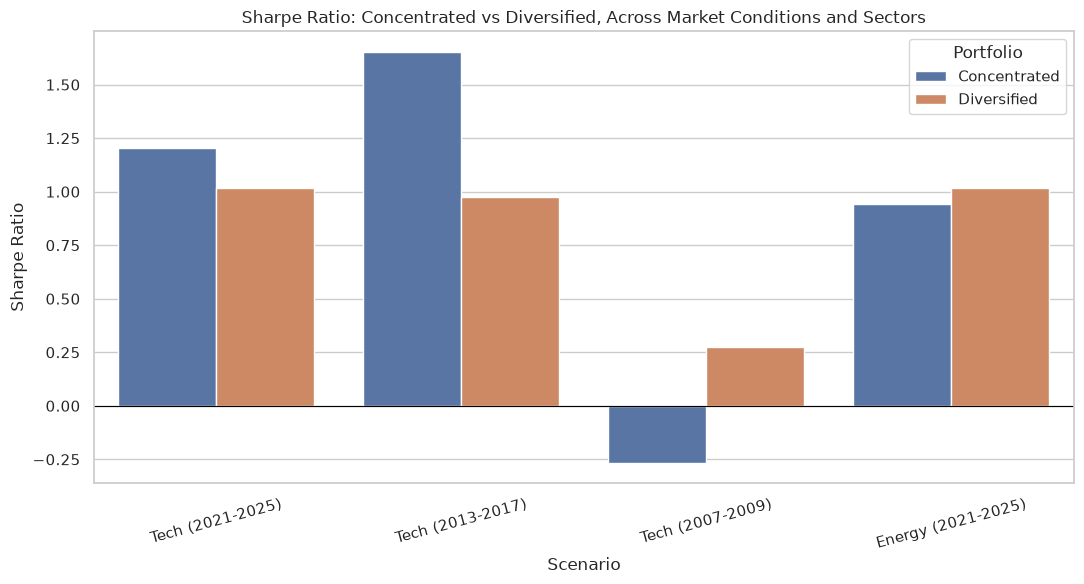

In [10]:
#Create a plot showing the sharpe ratio for each of the above calcuations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

results_df["scenario"] = results_df["sector"] + " (" + results_df["start"].str[:4] + "-" + results_df["end"].str[:4] + ")"

plt.figure(figsize=(11, 6))
sns.barplot(data=results_df, x="scenario", y="sharpe", hue="portfolio")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.title("Sharpe Ratio: Concentrated vs Diversified, Across Market Conditions and Sectors")
plt.xlabel("Scenario")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=15)
plt.legend(title="Portfolio")
plt.tight_layout()
plt.show()

Two things stand out. First, market conditions: tech concentration clearly outperformed diversification in both bull markets, then reversed sharply during the crisis. Second, sector matters independently of market conditions: holding the same favorable 2021–2025 window fixed, concentrating in energy instead of tech underperformed diversification, showing the original tech advantage wasn't about concentration generally, it was specific to tech's performance in that window.

The Sharpe ratio alone understates how dramatic this divergence actually was day to day. The chart below tracks cumulative return through the crisis for both portfolios.

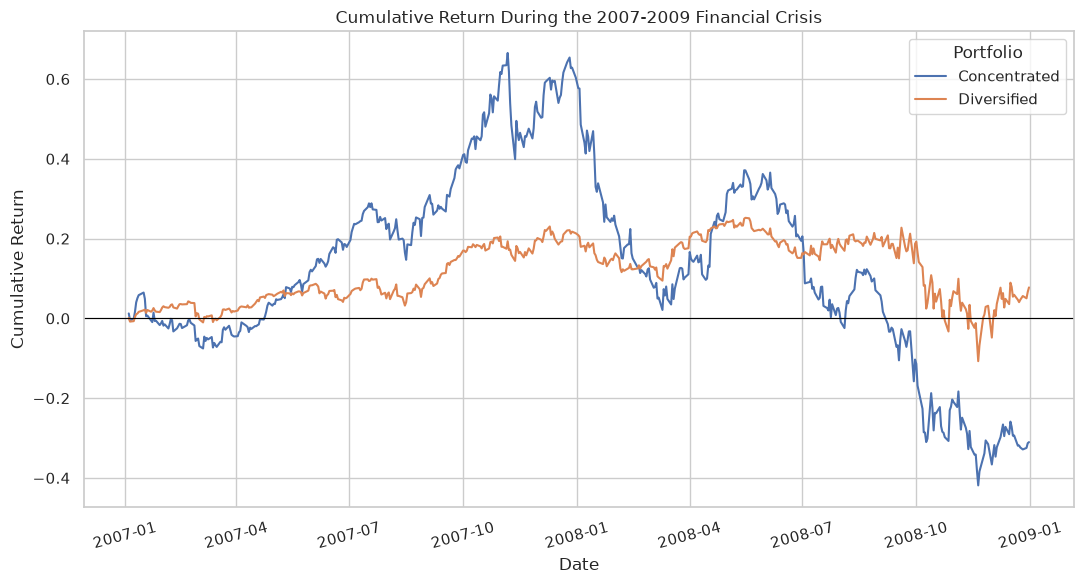

In [11]:
#Create a plot comparing the cumulative returns for the tech portfolio vs diversified portfolio during the financial crisis
crisis_returns_clean = crisis_returns.dropna(subset=["portfolio_return"]).copy()
crisis_returns_clean["cumulative_return"] = crisis_returns_clean.groupby("Portfolio")["portfolio_return"].transform(lambda x: (1 + x).cumprod() - 1)
crisis_returns_clean["Date"] = pd.to_datetime(crisis_returns_clean["Date"])

plt.figure(figsize=(11, 6))
sns.lineplot(data=crisis_returns_clean, x="Date", y="cumulative_return", hue="Portfolio")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.title("Cumulative Return During the 2007-2009 Financial Crisis")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The concentrated portfolio climbed to a 65% cumulative gain by late 2007, then collapsed to a 40% loss by late 2008, a swing of over 100 percentage points. The diversified portfolio moved in a far narrower band throughout, never exceeding roughly 25% gain or falling much below zero. This is the practical, visible meaning behind the Sharpe ratio numbers: concentration didn't just underperform during the crisis, it was dramatically more volatile getting there.

## Conclusion

Whether a concentrated portfolio outperforms a diversified one depends on at least two separable factors, both demonstrated directly in this analysis:

- **Market conditions**: Tech concentration outperformed diversification in both bull markets tested (Sharpe 1.20 and 1.65 vs. 0.98–1.02) but underperformed sharply during the 2007–2009 financial crisis (Sharpe -0.27 vs. 0.27).
- **Sector choice**: Holding the same favorable 2021–2025 period fixed, concentrating in energy instead of tech reversed the result entirely (Sharpe 0.94 vs. 1.02), showing the original tech advantage was sector-specific, not a general property of concentration.

Diversification's real value shown here isn't higher average returns, it's meaningfully lower volatility and a narrower range of outcomes, particularly valuable during a genuine downturn, exactly the tradeoff diversification is designed to manage.

**Limitations:** This analysis covers a limited number of discrete time windows and two sectors; it does not test every possible market condition or sector combination, and results from any single historical period may not generalize forward. The reusable function built here makes further testing straightforward, additional sectors, longer or rolling time windows, or a broader multi-factor regression could extend this analysis further.